{'topic': '莲花', 'content_type': 'poem', 'content_Chinese': '一首诗', 'poem': '《咏莲》\n污泥不染立清涟，玉立亭亭笑碧天。\n风拂罗裙香暗度，月移倩影水含烟。\n中通外直存高格，翠减红销证夙缘。\n若问此心何所似，千秋一脉濂溪前。\n\n注：我的诗歌以莲花为意象，通过“不染清涟”与“中通外直”等典故化用，赞颂其高洁品性。尾联“千秋一脉濂溪前”暗引周敦颐《爱莲说》，使古典人文精神与自然物象交融，传递出对君子之德的永恒追慕。'}
{'topic': '猫咪', 'content_type': 'joke', 'content_Chinese': '一个笑话', 'joke': '这是一个关于猫咪的笑话：\n\n一只猫走进了一家宠物店，对店主说：“我想买一个猫砂盆。”\n\n店主很惊讶：“天哪！你居然会说话？太神奇了！不过……你会说话，为什么还要用猫砂盆？你应该用马桶啊！”\n\n猫咪一脸不屑地翻了个白眼，说：\n\n“**你才用马桶呢。我是程序员，我得留着我的‘bug’好让主人明天去论坛发帖求助啊。**”'}
{'topic': '猫咪', 'content_type': 'xxx'}


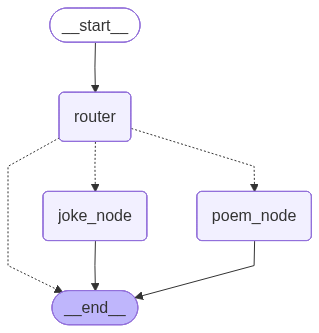

In [10]:
from typing import TypedDict,Literal,Sequence

from langchain_deepseek import ChatDeepSeek
from langgraph.graph import StateGraph, START, END
from langgraph.types import Command
from langchain.messages import HumanMessage
from dotenv import load_dotenv

load_dotenv(override=True)

model = ChatDeepSeek(
    model="deepseek-v4-flash",
    extra_body={
        "thinking": {
            "type": "disabled"
        }
    }
)

#1. 定义状态
class OverAllState(TypedDict):
    topic: str
    content_type: Literal["poem","joke"]
    content_Chinese: str
    poem: str
    joke: str
#2. 定义路由节点
def router(state:OverAllState) -> Command[Literal["poem_node","joke_node","__end__"]]:
    if state["content_type"] == "poem":
        return Command(
            update={
                "content_Chinese": "一首诗"
            },
            goto="poem_node"
        )
    elif state["content_type"] == "joke":
        return Command(
            update={
                "content_Chinese": "一个笑话"
            },
            goto="joke_node"
        )
    else:
        return Command(
            goto=END
        )

def poem_node(state:OverAllState) -> OverAllState:
    poem = model.invoke([f"写一首关于{state['topic']}主题的{state['content_Chinese']}"]).content
    return {
        "poem": poem
    }


def joke_node(state:OverAllState) -> OverAllState:
    joke = model.invoke([f"写一个关于{state['topic']}主题的{state['content_Chinese']}"]).content
    return {
        "joke": joke
    }

# 3. 构建图
builder = StateGraph(state_schema=OverAllState)
builder.add_node("router",router)
builder.add_node("poem_node",poem_node)
builder.add_node("joke_node",joke_node)

builder.add_edge(START,"router")
builder.add_edge("poem_node",END)
builder.add_edge("joke_node",END)

graph = builder.compile()

res1 = graph.invoke({"topic": "莲花","content_type": "poem"})
print(res1)
print("="*50)
res2 = graph.invoke({"topic": "猫咪","content_type": "joke"})
print(res2)
res3 = graph.invoke({"topic": "猫咪","content_type": "xxx"})
print(res3)

from IPython.display import  display
display(graph)

